# **3.6 Implementing Softmax Regression from Scratch**
Just as we implemented linear regression from scratch, we believe that softmax regression is also an important foundation, so it is important to understand the details of its implementation. In this section, we will use the Fashion-MNIST dataset introduced in [Section 3.5](./image_classification_dataset.ipynb#35) and set the batch size of the data iterator to 256.

In [1]:
import torch
from IPython import display
from d2l import torch as d2l
from d2l.torch import Accumulator

print(d2l.__file__)

import inspect
print(inspect.getsourcefile(d2l.load_data_fashion_mnist))
print(inspect.signature(d2l.load_data_fashion_mnist))
# the code bellow helps find out the path the function uses to locate the dataset

D:\CodeProject\Python\d2l_study\d2l\torch.py
D:\CodeProject\Python\d2l_study\d2l\torch.py
(batch_size, root='../data', resize=None)


In [2]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, root="../../data")

## **3.6.1 Initialize Model Parameters**
As in the previous example of linear regression, each sample here will be represented by a vector of fixed length. Each sample in the original dataset is a 28×28 image. In this section, we will flatten each image and treat them as vectors of length 784. In later chapters, we will discuss features that can take advantage of the spatial structure of images, but for now, we will treat each pixel location as a single feature.<br><br>
Recall that in softmax regression, we have as many output values as there are classes. Since our dataset has 10 classes, the network’s output dimension is 10. Therefore, the weights will form a 784×10 matrix, and the bias will form a 1×10 row vector. As with linear regression, we will initialize our weights W using a normal distribution and initialize the bias to 0.

In [3]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

## **3.6.2 Define the softmax operation**
Before implementing the softmax regression model, let’s briefly review how the sum operator works along specific dimensions of a tensor. As described in [Section 2.3.6](../../chapter_preliminaries/content/data_manipulation.ipynb##236), given a matrix X, we can sum over all elements (by default). We can also sum only over elements along a single axis—that is, along the same column (axis 0) or the same row (axis 1). If X is a tensor of shape (2, 3) and we sum along the columns, the result will be a vector of shape (3,). When calling the sum operator, we can specify the number of axes to preserve from the original tensor, rather than collapsing the dimensions being summed. This will produce a two-dimensional tensor of shape (1, 3).

In [4]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

Let’s recall that implementing softmax consists of three steps:

 1. Calculate the power of each term (using exp);
 2. Sum each row (where each sample in a small batch is a row) to obtain the normalization constant for each sample;
 3. Divide each row by its normalization constant to ensure that the sum of the results is 1.<br><br>

Before looking at the code, let's review this expression:
##### **(3.6.1)**
$$softmax(X)_{ij}=\frac{exp(X_{ij})}{\sum_{k}exp(X_{ik})}$$

In [5]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition # A broadcast mechanism is used here.

As shown in the code above, for any random input, we convert each element into a non-negative number. Furthermore, based on the principles of probability, the sum of each row is 1.

In [7]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1, keepdim=True)

(tensor([[0.1869, 0.1091, 0.2037, 0.0760, 0.4243],
         [0.1698, 0.3004, 0.2930, 0.0958, 0.1410]]),
 tensor([[1.0000],
         [1.0000]]))

## **3.6.3 Define the Model**
Once we have defined the softmax operation, we can implement a softmax regression model. The code below defines how inputs are mapped to outputs through the network. **Note that before passing the data to the model, we use the `reshape` function to flatten each raw image into a vector.**

In [8]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

## **3.6.4 Define the Loss function**
Next, we will implement the cross-entropy loss function introduced in [Section 3.4](./softmax_regression.ipynb). This is likely the most common loss function in deep learning, since **there are currently far more classification problems than regression problems.**<br><br>
Here, we do not use a Python `for` loop to iterate through the predictions (which is often inefficient), but instead select all elements using a single operator. Next, we create a data sample `y_hat` containing the predicted probabilities for two samples across three classes, along with their corresponding labels `y`. With `y`, we know that for the first sample, Class 1 is the correct prediction; and for the second sample, Class 3 is the correct prediction. Then, using `y` as an index for the probabilities in `y_hat`, we select the probability for Class 1 in the first sample and the probability for Class 3 in the second sample.

In [9]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

Now we can implement the cross-entropy loss function with just one line of code.

In [10]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

## **3.6.5 Classification Accuracy**
Given a predicted probability distribution y_hat, when we must output a hard prediction, we typically select the class with the highest predicted probability. Many applications require us to make a choice. For example, Gmail must classify emails as “Primary,” “Social,” “Updates,” or “Forums.” While Gmail may internally estimate probabilities during classification, it must ultimately choose one class.<br><br>
A prediction is correct when it matches the class label y. Classification accuracy is the ratio of the number of correct predictions to the total number of predictions. Although it can be difficult to optimize accuracy directly (because the accuracy function is not differentiable), accuracy is typically the performance metric we care about most, and we almost always focus on it when training a classifier.<br><br>
To ensure computational accuracy, we perform the following steps. First, if y_hat is a matrix, we assume that the second dimension stores the predicted scores for each class. We use `argmax` to obtain the index of the maximum element in each row to determine the predicted class. We then compare the predicted class with the corresponding `y` element. Since the equality operator “==” is sensitive to data types, we convert the data type of `y_hat` to match that of `y`. The result is a tensor containing 0s (incorrect) and 1s (correct). Finally, we sum these values to obtain the number of correct predictions.

In [11]:
def accuracy(y_hat, y):
    """Calculate the number of correct predictions"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

We will continue to use the previously defined variables `y_hat` and `y` as the predicted probability distribution and the label, respectively. As can be seen, the predicted class for the first sample is 2 (the maximum element in that row is 0.6, at index 2), which does not match the actual label of 0. The predicted class for the second sample is 2 (the maximum element in that row is 0.5, at index 2), which matches the actual label of 2. Therefore, the classification accuracy for these two samples is 0.5.

In [12]:
accuracy(y_hat, y) / len(y)

0.5

Similarly, for any dataset accessible via the data iterator `data_iter`, we can evaluate the accuracy of any model `net`.

In [13]:
def evaluate_accuracy(net, data_iter): #@save
    """Calculate the model's accuracy on a specified dataset"""
    if isinstance(net, torch.nn.Module):
        net.eval() # Set the model to evaluation mode
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

Here, we define a utility class called `Accumulator`, which is used to accumulate values across multiple variables. In the `evaluate_accuracy` function above, we created two variables within an `Accumulator` instance—one to store the number of correct predictions and the other to store the total number of predictions. As we iterate through the dataset, both values will accumulate over time.

In [14]:
class Accumulator: #@save
    """Accumulate over n variables"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

Since we initialize the neural network model with random weights, its accuracy should be close to that of a random guess. For example, in a scenario with 10 classes, the accuracy is 0.1.

In [15]:
evaluate_accuracy(net, test_iter)

0.0684

## **3.6.6 Training**
Now that we’ve looked at the linear regression implementation in [Section 3.2](./concise_implementation_of_linear_regression.ipynb), the code for the softmax regression training process should look very familiar. Here, we refactor the training process to make it reusable. First, we define a function to train for one iteration. Note that `updater` is a common function used to update model parameters; it accepts the batch size as an argument. It can be the `d2l.sgd` function or one of the framework’s built-in optimizers.

In [16]:
def train_epoch_ch3(net, train_iter, loss, updater): #@save
    """One training iteration cycle"""
    # Set the model to training mode
    if isinstance(net, torch.nn.Module):
        net.train()

    # Total training loss, total training accuracy, number of samples
    metric = Accumulator(3)
    for X, y in train_iter:
        # calculate the graditude and update the parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]

Before presenting the implementation of the training function, we’ll define a utility class called `Animator` that draws data in an animation; this will simplify the code in the rest of this book.

In [17]:
class Animator: #@save
    """Plotting Data in an Animation"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Draw Multiple Lines Incrementally
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Using Lambda Functions to Capture Parameters
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend
        )
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add Multiple Data Points to a Chart
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


Next, we’ll implement a training function that trains a model `net` on the training dataset accessed via `train_iter`. This training function will run for multiple iterations (specified by `num_epochs`). At the end of each iteration, the model will be evaluated using the test dataset accessed via `test_iter`. We’ll use the `Animator` class to visualize the training progress.

In [18]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater): #@save
    """Training the model"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train_loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))

    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert 1 >= train_acc > 0.7, train_acc
    assert 1 >= test_acc > 0.7, test_acc

As an implementation starting from scratch, we use the mini-batch stochastic gradient descent defined in [Section 3.2](./concise_implementation_of_linear_regression.ipynb) to optimize the model’s loss function, setting the learning rate to 0.1.

In [19]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

Now, we will train the model for 10 epochs. **Please note that the number of epochs (num_epochs) and the learning rate (lr) are both adjustable hyperparameters. By changing their values, we can improve the model’s classification accuracy.**

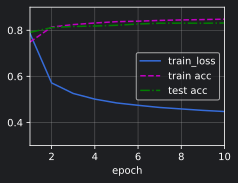

In [20]:
num_epochs = 10
train_ch3(net,train_iter, test_iter, cross_entropy, num_epochs, updater)

## **3.6.7 Forecast**
Now that training is complete, our model is ready to make classification predictions on images. Given a set of images, we will compare their actual labels (the first line of the text output) with the model’s predictions (the second line of the text output).

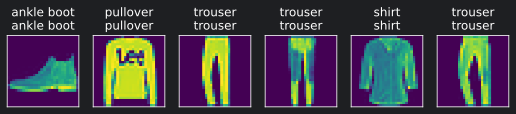

In [21]:
def predict_ch3(net, test_iter, n=6): #@save
    """Predicting the label"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0: n].reshape((n, 28, 28)), 1, n, titles=titles[0:n]
    )

predict_ch3(net, test_iter)

## **Summary**
* Using softmax regression, we can train a multi-class classification model.
* Training a recurrent softmax regression model is very similar to training a linear regression model: first, read the data; then, define the model and the loss function; and finally, train the model using an optimization algorithm. Most common deep learning models follow a similar training process.